Import Libraries

In [1]:
import sys
from pathlib import Path

# Project root directory
project_root = Path().resolve().parent

# Add project root to Python path
sys.path.append(str(project_root))

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from src.config import RAW_DATA_PATH
from src.data_loader import load_data

Load Dataset

In [3]:
df = load_data(RAW_DATA_PATH)

✅ Dataset loaded successfully.


In [4]:
df.head()
df.shape
df.columns
df.dtypes
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dt.day_name()
# df.info()
df.shape
df.isnull().sum()
# df["City"].nunique()
df["City"].unique

<bound method Series.unique of 0            Ahmedabad
1            Ahmedabad
2            Ahmedabad
3            Ahmedabad
4            Ahmedabad
             ...      
29526    Visakhapatnam
29527    Visakhapatnam
29528    Visakhapatnam
29529    Visakhapatnam
29530    Visakhapatnam
Name: City, Length: 29531, dtype: str>

# Day 3 - Data Cleaning

## Step 1: Missing Value Analysis

array([[<Axes: title={'center': 'PM2.5'}>,
        <Axes: title={'center': 'PM10'}>],
       [<Axes: title={'center': 'CO'}>,
        <Axes: title={'center': 'Xylene'}>]], dtype=object)

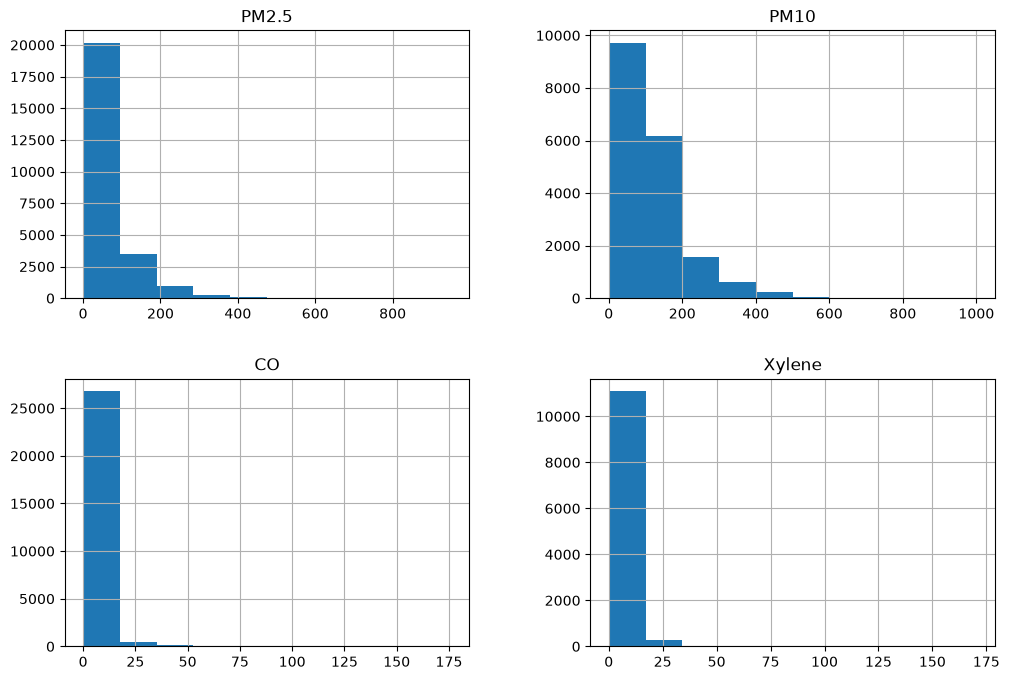

In [5]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })
    .sort_values(by="Missing Percentage", ascending=False)
)

missing_df
df[["PM2.5", "PM10", "CO", "Xylene"]].describe().T
df[["PM2.5", "PM10", "CO", "Xylene"]].hist(figsize=(12, 8))



In [6]:
# Remove rows where target variables are missing
df = df.dropna(subset=["AQI", "AQI_Bucket"])

print("New Shape:", df.shape)

New Shape: (24850, 16)


In [7]:
df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

Observation:

Xylene has 61.32% missing values, making it the most incomplete feature in the dataset.
It also shows a weak correlation (0.1655) with the target variable (AQI).
Since a large portion of the column would require imputation, it could distort the original feature distribution without providing significant predictive value.
Therefore, Xylene is a suitable candidate for removal.

In [8]:
# drop Xylene column 
df = df.drop(columns=["Xylene"])

print(df.shape)

(24850, 15)


We removed the Xylene feature from the dataset. The number of rows remained the same because only a column was removed. The dataset now contains 24,850 observations and 15 features.

In [9]:
df.isnull().sum()

City             0
Date             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
AQI              0
AQI_Bucket       0
dtype: int64

In [10]:
# Numerical columns with missing values
numerical_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

# Fill missing values using median
for column in numerical_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)


In [11]:
numerical_columns.append("New_Column")
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [12]:
# Final Preprocessed Dataset
df.to_csv("../data/processed/cleaned_aqi.csv", index=False)

print("✅ Cleaned dataset saved successfully.")



✅ Cleaned dataset saved successfully.


Observation:
PM10 has 37.7% missing values.

Reason:
It has a strong correlation (0.80) with AQI and is an important predictor.

Decision:
Retain the feature and use median imputation because the distribution is right-skewed and contains outliers.

In [13]:
print(df["Date"].min())
print(df["Date"].max())

2015-01-01 00:00:00
2020-07-01 00:00:00


In [14]:
df["Year"] = df["Date"].dt.year
df[["Date" , "Year"]].head()

,Date,Year
28,2015-01-29,2015
29,2015-01-30,2015
30,2015-01-31,2015
31,2015-02-01,2015
32,2015-02-02,2015


The Year feature helps the model capture long-term trends in air quality. Pollution levels may change over time due to government policies, industrial growth, seasonal variation, or environmental changes.

In [15]:
df["Month"] = df["Date"].dt.month
df[["Date" , "Year" , "Month"]].head()

,Date,Year,Month
28,2015-01-29,2015,1
29,2015-01-30,2015,1
30,2015-01-31,2015,1
31,2015-02-01,2015,2
32,2015-02-02,2015,2


In [16]:
df["Year"].value_counts().sort_values()

Year
2015    1827
2016    2573
2017    3234
2020    4421
2018    5724
2019    7071
Name: count, dtype: int64

In [17]:
yearly_aqi = df.groupby("Year")["AQI"].mean()
print(yearly_aqi)


Year
2015    212.463054
2016    197.150019
2017    181.472789
2018    182.684312
2019    156.518173
2020    113.520697
Name: AQI, dtype: float64


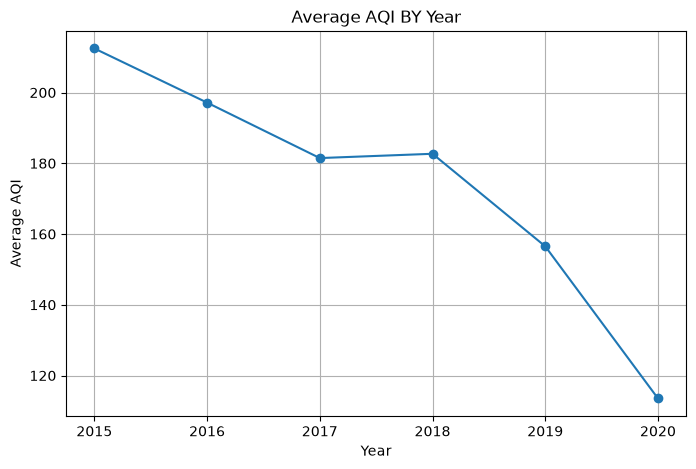

In [18]:
yearly_aqi.plot(kind="line" , marker="o", figsize=(8,5))
plt.title("Average AQI BY Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

Rule
Situation	Best Chart
<!-- Year-wise trend	✅ Line Chart -->
<!-- Month-wise trend	✅ Line Chart -->
<!-- Daily trend	✅ Line Chart -->
<!-- City comparison	✅ Bar Chart -->
<!-- Pollutant comparison	✅ Bar Chart -->
<!-- Category percentage	✅ Pie Chart -->
<!-- Relationship between two numerical features	✅ Scatter Plot -->

"The x-axis represents time (Year), and my objective is to analyze how AQI changes over time. A line chart clearly highlights increasing or decreasing trends, making it more suitable than a bar chart for time-series data."

In [19]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"



In [20]:
df["Season"] = df["Month"].apply(get_season)
df[["Month", "Season"]].head(10)

,Month,Season
28,1,Winter
29,1,Winter
30,1,Winter
31,2,Winter
32,2,Winter
33,2,Winter
34,2,Winter
35,2,Winter
36,2,Winter
37,2,Winter


In [21]:
df["City"].unique()
df["City"].value_counts()

City
Delhi                 1999
Bengaluru             1910
Lucknow               1893
Chennai               1884
Hyderabad             1880
Patna                 1459
Gurugram              1453
Ahmedabad             1334
Visakhapatnam         1171
Amritsar              1126
Jaipur                1094
Thiruvananthapuram    1052
Amaravati              841
Mumbai                 775
Jorapokhar             771
Kolkata                754
Brajrajnagar           713
Talcher                698
Guwahati               495
Coimbatore             344
Chandigarh             299
Bhopal                 278
Shillong               205
Kochi                  158
Ernakulam              153
Aizawl                 111
Name: count, dtype: int64

In [22]:
x= df.drop(columns=["AQI" , "AQI_Bucket"])
y_reg = df["AQI"]
y_clf = df["AQI_Bucket"]

In [23]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_reg_train , y_reg_test ,  y_clf_train , y_clf_test = train_test_split(x , y_reg , y_clf , test_size = 0.2 , random_state = 42)

In [24]:
x_train = x_train.drop(columns=["Date"])
x_test = x_test.drop(columns=["Date"])

In [25]:
print(x_train.shape)
print(x_test.shape)

(19880, 15)
(4970, 15)


In [26]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore" , sparse_output=False)

In [27]:
city_train = encoder.fit_transform(x_train[["City"]])
city_test = encoder.fit_transform(x_test[["City"]])

In [28]:
print(city_train.shape)
print(city_test.shape)

(19880, 26)
(4970, 26)


In [29]:
print(encoder.get_feature_names_out())

['City_Ahmedabad' 'City_Aizawl' 'City_Amaravati' 'City_Amritsar'
 'City_Bengaluru' 'City_Bhopal' 'City_Brajrajnagar' 'City_Chandigarh'
 'City_Chennai' 'City_Coimbatore' 'City_Delhi' 'City_Ernakulam'
 'City_Gurugram' 'City_Guwahati' 'City_Hyderabad' 'City_Jaipur'
 'City_Jorapokhar' 'City_Kochi' 'City_Kolkata' 'City_Lucknow'
 'City_Mumbai' 'City_Patna' 'City_Shillong' 'City_Talcher'
 'City_Thiruvananthapuram' 'City_Visakhapatnam']


In [30]:
print(x_train["City"].iloc[0])
print(city_train[0])


Amaravati
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [31]:
city = x_train["City"].iloc[0]

print("Actual City:", city)

print("Encoded City:", city_train[0])

print("Active Column:",
      encoder.get_feature_names_out()[city_train[0].argmax()])

Actual City: Amaravati
Encoded City: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Active Column: City_Amaravati


In [32]:
city_columns = encoder.get_feature_names_out()

In [33]:
city_train_df = pd.DataFrame(
    city_train,
    columns=city_columns,
    index=x_train.index
)

city_test_df = pd.DataFrame(
    city_test ,
    columns=city_columns,
    index = x_test.index
)

In [34]:
x_train = x_train.drop(columns=["City"])
x_test = x_test.drop(columns=["City"])

In [35]:
x_train = pd.concat([x_train , city_train_df] , axis=1)
x_test  = pd.concat([x_test , city_test_df], axis=1)

In [36]:
print(x_train.shape)
print(x_test.shape)

(19880, 40)
(4970, 40)


In [37]:
season_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [38]:
season_train = season_encoder.fit_transform(
    x_train[["Season"]]
)

In [39]:
season_test = season_encoder.transform(
    x_test[["Season"]]
)

In [40]:
print(season_encoder.get_feature_names_out())

['Season_Monsoon' 'Season_Post-Monsoon' 'Season_Summer' 'Season_Winter']


In [41]:
print(season_train.shape)
print(season_test.shape)

(19880, 4)
(4970, 4)


In [42]:
season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns=season_columns,
    index = x_train.index
)

season_test_df = pd.DataFrame(
     season_train,
        columns=season_columns,
        index = x_train.index
)

In [43]:
x_train = x_train.drop(columns=["Season"])
x_test = x_test.drop(columns=["Season"])

In [44]:
x_train = pd.concat([x_train , season_train_df] , axis=1)
X_test = pd.concat([x_test, season_test_df], axis=1)

print(x_train.shape)
print(x_test.shape)

(19880, 43)
(4970, 39)


In [45]:
print("Train columns:", len(x_train.columns))
print("Test columns:", len(X_test.columns))

print("Columns in train but not test:")
print(set(x_train.columns) - set(X_test.columns))

print("Columns in test but not train:")
print(set(X_test.columns) - set(x_train.columns))

print(x_train.dtypes)
print(x_train.select_dtypes(include="object").columns)

Train columns: 43
Test columns: 43
Columns in train but not test:
set()
Columns in test but not train:
set()
PM2.5                      float64
PM10                       float64
NO                         float64
NO2                        float64
NOx                        float64
NH3                        float64
CO                         float64
SO2                        float64
O3                         float64
Benzene                    float64
Toluene                    float64
Year                         int32
Month                        int32
City_Ahmedabad             float64
City_Aizawl                float64
City_Amaravati             float64
City_Amritsar              float64
City_Bengaluru             float64
City_Bhopal                float64
City_Brajrajnagar          float64
City_Chandigarh            float64
City_Chennai               float64
City_Coimbatore            float64
City_Delhi                 float64
City_Ernakulam             float64
City_Gurugram   

In [46]:
print(df[["City" , "Date" , "PM2.5"]].head(10))
print(df["Date"].min())
print(df["Date"].max())

print(df.groupby("City")["Date"].nunique().describe())

         City       Date   PM2.5
28  Ahmedabad 2015-01-29   83.13
29  Ahmedabad 2015-01-30   79.84
30  Ahmedabad 2015-01-31   94.52
31  Ahmedabad 2015-02-01  135.99
32  Ahmedabad 2015-02-02  178.33
33  Ahmedabad 2015-02-03  139.70
34  Ahmedabad 2015-02-04   80.65
35  Ahmedabad 2015-02-05   58.36
36  Ahmedabad 2015-02-06   79.29
37  Ahmedabad 2015-02-07   88.70
2015-01-01 00:00:00
2020-07-01 00:00:00
count      26.000000
mean      955.769231
std       620.381967
min       111.000000
25%       381.750000
50%       808.000000
75%      1423.250000
max      1999.000000
Name: Date, dtype: float64


In [47]:
df= df.sort_values(["City" , "Date"]).reset_index(drop=True)

print(df[["City" , "Date" , "PM2.5"]].head(10))

        City       Date   PM2.5
0  Ahmedabad 2015-01-29   83.13
1  Ahmedabad 2015-01-30   79.84
2  Ahmedabad 2015-01-31   94.52
3  Ahmedabad 2015-02-01  135.99
4  Ahmedabad 2015-02-02  178.33
5  Ahmedabad 2015-02-03  139.70
6  Ahmedabad 2015-02-04   80.65
7  Ahmedabad 2015-02-05   58.36
8  Ahmedabad 2015-02-06   79.29
9  Ahmedabad 2015-02-07   88.70


In [48]:
df["PM2.5_lag1"] = df.groupby("City")["PM2.5"].shift(1)
df[["City" , "Date" , "PM2.5" , "PM2.5_lag1"]].head(10)
df["PM2.5_lag1"].isnull().sum()

np.int64(26)

In [49]:
df[df["PM2.5_lag1"].isnull()]["City"].nunique()
df[df["PM2.5_lag1"].isnull()]["City"].tolist()

['Ahmedabad',
 'Aizawl',
 'Amaravati',
 'Amritsar',
 'Bengaluru',
 'Bhopal',
 'Brajrajnagar',
 'Chandigarh',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Ernakulam',
 'Gurugram',
 'Guwahati',
 'Hyderabad',
 'Jaipur',
 'Jorapokhar',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Mumbai',
 'Patna',
 'Shillong',
 'Talcher',
 'Thiruvananthapuram',
 'Visakhapatnam']

In [50]:
df=df.dropna(subset=["PM2.5_lag1"]).reset_index(drop=True)
print(df.shape)
print(df["PM2.5_lag1"].isnull().sum())

(24824, 19)
0


In [51]:
df["PM2.5_rolling3"] = (
    df.groupby("City")["PM2.5"]
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

df[["City" , "Date" , "PM2.5" , "PM2.5_lag1" , "PM2.5_rolling3"]].head(10)

,City,Date,PM2.5,PM2.5_lag1,PM2.5_rolling3
0,Ahmedabad,2015-01-30,79.84,83.13,NaN
1,Ahmedabad,2015-01-31,94.52,79.84,NaN
2,Ahmedabad,2015-02-01,135.99,94.52,NaN
3,Ahmedabad,2015-02-02,178.33,135.99,103.450000
4,Ahmedabad,2015-02-03,139.70,178.33,136.280000
5,Ahmedabad,2015-02-04,80.65,139.70,151.340000
6,Ahmedabad,2015-02-05,58.36,80.65,132.893333
7,Ahmedabad,2015-02-06,79.29,58.36,92.903333
8,Ahmedabad,2015-02-07,88.70,79.29,72.766667
9,Ahmedabad,2015-02-08,74.28,88.70,75.450000


Rolling average itself doesn't make the prediction "accurate."
It gives the model recent pollution trend information, which may improve prediction if that recent trend is predictive of today's AQI.

In [52]:
df["PM2.5_rolling3"].isnull().sum()

np.int64(78)

In [53]:
df= df.dropna(subset=["PM2.5_rolling3"]).reset_index(drop=True)
print(df.shape)
print(df["PM2.5_rolling3"].isnull().sum())

(24746, 20)
0


In [54]:
x=df.drop(columns=["AQI" , "AQI_Bucket"])
y_reg= df["AQI"]
y_clf= df["AQI_Bucket"]

print(df["Date"].min())
print(df["Date"].max())

print(df["Year"].value_counts().sort_index())

2015-01-05 00:00:00
2020-07-01 00:00:00
Year
2015    1799
2016    2565
2017    3210
2018    5712
2019    7051
2020    4409
Name: count, dtype: int64


In [55]:
train_df = df[df["Year"] < 2020 ].copy()
test_df = df[df["Year"] == 2020].copy()

print("Train:" , train_df.shape)
print("Test:" , test_df.shape)

Train: (20337, 20)
Test: (4409, 20)


In [56]:
x_train = train_df.drop(columns=["AQI" , "AQI_Bucket" , "Date"])
x_test = test_df.drop(columns=["AQI" , "AQI_Bucket" , "Date"])

y_reg_train = train_df["AQI"]
y_reg_test = test_df["AQI"]

y_clf_train = train_df["AQI_Bucket"]
y_clf_test = test_df["AQI_Bucket"]

print(x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

Index(['City', 'Season'], dtype='str')


In [57]:
from sklearn.preprocessing import OneHotEncoder

city_encoder = OneHotEncoder(
    handle_unknown = "ignore",
    sparse_output=False
)

In [58]:
city_train = city_encoder.fit_transform(x_train[["City"]])
city_test = city_encoder.transform(x_test[["City"]])

print(city_train.shape)
print(city_test.shape)

print(city_encoder.get_feature_names_out())

(20337, 23)
(4409, 23)
['City_Ahmedabad' 'City_Amaravati' 'City_Amritsar' 'City_Bengaluru'
 'City_Bhopal' 'City_Brajrajnagar' 'City_Chandigarh' 'City_Chennai'
 'City_Coimbatore' 'City_Delhi' 'City_Gurugram' 'City_Guwahati'
 'City_Hyderabad' 'City_Jaipur' 'City_Jorapokhar' 'City_Kolkata'
 'City_Lucknow' 'City_Mumbai' 'City_Patna' 'City_Shillong' 'City_Talcher'
 'City_Thiruvananthapuram' 'City_Visakhapatnam']


In [59]:
print("Train cities:")
print(sorted(x_train["City"].unique()))

print("\n Test-only cities:")
print(sorted(set(x_test["City"].unique()) - set(x_train["City"].unique())))

Train cities:
['Ahmedabad', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

 Test-only cities:
['Aizawl', 'Ernakulam', 'Kochi']


In [60]:
season_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

season_train = season_encoder.fit_transform(
    x_train[["Season"]]
)

season_test = season_encoder.transform(
    x_test[["Season"]]
)
print(season_train)
print(season_test)
print(season_encoder.get_feature_names_out())

[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
['Season_Monsoon' 'Season_Post-Monsoon' 'Season_Summer' 'Season_Winter']


Why did you use One-Hot Encoding for Season?
Season is a nominal categorical feature without a meaningful numerical ordering, so I used One-Hot Encoding instead of assigning arbitrary numeric labels.

Why sparse_output=False?
The dataset has only four season categories and 26 city categories, so the encoded feature space is small. I used dense output because it is easier to inspect and integrate with pandas, while sparse representation would be more useful for very high-cardinality categorical features.

In [61]:
city_columns  = city_encoder.get_feature_names_out()

city_train_df = pd.DataFrame(
    city_train,
    columns= city_columns,
    index = x_train.index
)

city_test_df = pd.DataFrame(
    city_test ,
    columns = city_columns,
    index = x_test.index
)


season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns= season_columns,
    index= x_train.index
)

season_test_df = pd.DataFrame(
    season_test ,
    columns = season_columns ,
    index = x_test.index
)

x_train  = pd.concat(
    [x_train , city_train_df , season_train_df] ,
    axis = 1
)

x_test = pd.concat(
    [x_test , city_test_df , season_test_df],
    axis=1
)

print(x_train.shape)
print(x_test.shape)


(20337, 44)
(4409, 44)


In [62]:
x_train = x_train.drop(columns=["City", "Season"])
x_test = x_test.drop(columns=["City", "Season"])

In [63]:
print("X_train" , x_train.shape)
print("X_test:" , x_test.shape)
print("y_train:" , y_reg_train.shape)
print("y_test:" , y_reg_test.shape)

X_train (20337, 42)
X_test: (4409, 42)
y_train: (20337,)
y_test: (4409,)


In [64]:
print("Missing Values in x_train:" , x_train.isnull().sum().sum()) 
print("Missing in x_test:" , x_test.isnull().sum().sum())

Missing Values in x_train: 0
Missing in x_test: 0


In [65]:
print(x_train.dtypes.value_counts())
print(x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

float64    40
int32       2
Name: count, dtype: int64
Index([], dtype='str')


In [66]:
city_encoder = OneHotEncoder(drop="first" ,
              handle_unknown="ignore",
              sparse_output=False
              )

season_encoder =  OneHotEncoder(drop="first" ,
              handle_unknown="ignore",
              sparse_output=False
              )

In [67]:
city_train = city_encoder.fit_transform(train_df[["City"]])
city_test = city_encoder.transform(test_df[["City"]])

season_train = season_encoder.fit_transform(train_df[["Season"]])
season_test = season_encoder.transform(test_df[["Season"]])

c:\Users\yash1\Desktop\AQI-Prediction-India\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [68]:
print("City:" , city_train.shape , city_test.shape)
print("Season:" , season_train.shape, season_test.shape)

City: (20337, 22) (4409, 22)
Season: (20337, 3) (4409, 3)


In [69]:
city_columns = city_encoder.get_feature_names_out()

city_train_df = pd.DataFrame(
    city_train,
    columns= city_columns,
    index = train_df.index
)

city_test_df = pd.DataFrame(
    city_test,
    columns=city_columns,
    index = test_df.index
)

# for season

season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns = season_columns,
    index = train_df.index
)

season_test_df = pd.DataFrame(
    season_test , 
    columns= season_columns,
    index = test_df.index
)

In [70]:
x_train = train_df.drop(columns=["AQI" , "AQI_Bucket" , "Date", "City" , "Season"])
x_test = test_df.drop(columns=["AQI" , "AQI_Bucket" , "Date", "City" , "Season"])

In [71]:
y_reg_train = train_df["AQI"]
y_reg_test = test_df["AQI"]

In [72]:
x_train = pd.concat(
    [x_train , city_train_df , season_train_df] ,
    axis = 1 
)

x_test = pd.concat(
    [x_test , city_test_df , season_test_df] ,
    axis= 1
)

In [73]:
print("x_train" , x_train.shape)
print("x_test" , x_test.shape)

print("Missing train:" , x_train.isnull().sum().sum())
print("Missing test:" , x_test.isnull().sum().sum())

print("Categorical:" ,
      x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

x_train (20337, 40)
x_test (4409, 40)
Missing train: 0
Missing test: 0
Categorical: Index([], dtype='str')


In [74]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

lr_model.fit(x_train , y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](40,)","[ 0.63, 0.28,-0.22,...,12.09, 7.54, 7.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](40,)","['PM2.5','PM10','NO',...,'Season_Post-Monsoon','Season_Summer', 'Season_Winter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,377.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,40
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(40)


In [75]:
y_pred_lr = lr_model.predict(x_test)
print(y_pred_lr[:10])

[262.32644244 257.49086957 293.14981201 314.77864843 263.09692118
 267.53727705 304.16868452 232.44960671 213.82847548 210.62971552]


In [76]:
comparison = pd.DataFrame({
    "Actual_AQI": y_reg_test.values ,
    "Predicted_AQI" : y_pred_lr 
})

print(comparison.head(10))

   Actual_AQI  Predicted_AQI
0       216.0     262.326442
1       162.0     257.490870
2       220.0     293.149812
3       254.0     314.778648
4       255.0     263.096921
5       175.0     267.537277
6       285.0     304.168685
7       157.0     232.449607
8       129.0     213.828475
9       129.0     210.629716


In [77]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_reg_test , y_pred_lr)
rmse = root_mean_squared_error(y_reg_test , y_pred_lr)
r2 = r2_score(y_reg_test , y_pred_lr)

print("MAE:" , mae )
print("RMSE:" , rmse)
print("R2:" , r2)

MAE: 23.26460009520929
RMSE: 34.58638734486476
R2: 0.8284970386034518


In [78]:
from sklearn .ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state= 42 ,
    n_jobs =-1
)

In [79]:
rf_model.fit(x_train, y_reg_train)
y_pred_rf = rf_model.predict(x_test)

In [80]:
print(y_pred_rf[:10])

[182.88 184.52 349.58 355.53 270.97 346.96 222.74 147.03 130.76 119.75]


In [81]:
mae_rf = mean_absolute_error(y_reg_test , y_pred_rf)
rmse_rf = root_mean_squared_error(y_reg_test , y_pred_rf) 
r2_rf  = r2_score(y_reg_test, y_pred_rf)

print("Random forest MAE:" , mae_rf)
print("Random forest RMSE:", rmse_rf)
print("Random Forest R2:" , r2_rf)

Random forest MAE: 12.91098661828079
Random forest RMSE: 24.443712753447564
Random Forest R2: 0.9143365493079447


In [82]:
comparison = pd.DataFrame({
    "Actual_AQI": y_reg_test.values ,
    "Predicted_AQI" : y_pred_rf 
})

print(comparison.head(10))

   Actual_AQI  Predicted_AQI
0       216.0         182.88
1       162.0         184.52
2       220.0         349.58
3       254.0         355.53
4       255.0         270.97
5       175.0         346.96
6       285.0         222.74
7       157.0         147.03
8       129.0         130.76
9       129.0         119.75


✅ "Random Forest achieved an MAE of 12.91, RMSE of 24.44, and R² of 0.9143 on the 2020 temporal test set, substantially outperforming the Linear Regression baseline."

In [83]:
y_train_pred_rf = rf_model.predict(x_train)

train_r2_rf = r2_score(y_reg_train , y_train_pred_rf)
test_r2_rf = r2_score(y_reg_test , y_pred_rf)

print("Train R2:" , train_r2_rf)
print("Test R2:" , test_r2_rf)

Train R2: 0.9883895778330662
Test R2: 0.9143365493079447


In [84]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

PM2.5             0.430654
CO                0.371565
PM2.5_lag1        0.067429
NO                0.038237
PM10              0.031995
O3                0.010367
NOx               0.009116
SO2               0.007301
NO2               0.006246
PM2.5_rolling3    0.005772
Toluene           0.004985
Benzene           0.003978
Year              0.003466
Month             0.003170
NH3               0.001593
dtype: float64


In [85]:
rf_tuned = RandomForestRegressor(
    n_estimators=100 ,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(x_train , y_reg_train)
y_pred_rf_tuned = rf_tuned.predict(x_test)

In [86]:
mae_rf_tuned = mean_absolute_error(y_reg_test, y_pred_rf_tuned)
rmse_rf_tuned = root_mean_squared_error(y_reg_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_reg_test, y_pred_rf_tuned)

print("Tuned RF MAE :", mae_rf_tuned)
print("Tuned RF RMSE:", rmse_rf_tuned)
print("Tuned RF R²  :", r2_rf_tuned)

Tuned RF MAE : 12.655870461369346
Tuned RF RMSE: 23.42203955674953
Tuned RF R²  : 0.9213478422132064


In [87]:
y_train_pred_tuned = rf_tuned.predict(x_train)

print("Train R²:", r2_score(y_reg_train, y_train_pred_tuned))
print("Test R² :", r2_rf_tuned)

Train R²: 0.9762833809571627
Test R² : 0.9213478422132064


In [88]:
print("Tuned RF MAE :", mean_absolute_error(y_reg_test, y_pred_rf_tuned))
print("Tuned RF RMSE:", root_mean_squared_error(y_reg_test, y_pred_rf_tuned))

Tuned RF MAE : 12.655870461369346
Tuned RF RMSE: 23.42203955674953


In [89]:
print(y_clf_train.value_counts())
print()
print(y_clf_train.value_counts(normalize=True)* 100)

AQI_Bucket
Moderate        7318
Satisfactory    6245
Poor            2487
Very Poor       2193
Severe          1291
Good             803
Name: count, dtype: int64

AQI_Bucket
Moderate        35.983675
Satisfactory    30.707577
Poor            12.228942
Very Poor       10.783301
Severe           6.348036
Good             3.948468
Name: proportion, dtype: float64


In [90]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_clf_train_encoded = label_encoder.fit_transform(y_clf_train)
y_clf_test_encoded = label_encoder.transform(y_clf_test)

print(label_encoder.classes_)

['Good' 'Moderate' 'Poor' 'Satisfactory' 'Severe' 'Very Poor']


In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state = 42,
    n_jobs = -1

)

rf_clf.fit(x_train , y_clf_train_encoded)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [102]:
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Make predictions
y_pred_clf = rf_clf.predict(x_test)

# Step 2: Calculate accuracy
accuracy = accuracy_score(
    y_clf_test_encoded,
    y_pred_clf
)

# Step 3: Print accuracy
print("Accuracy:", accuracy)

# Step 4: Print detailed classification report
print(
    classification_report(
        y_clf_test_encoded,
        y_pred_clf,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.8233159446586528
              precision    recall  f1-score   support

        Good       0.90      0.54      0.68       529
    Moderate       0.85      0.82      0.84      1477
        Poor       0.81      0.74      0.77       287
Satisfactory       0.79      0.91      0.85      1944
      Severe       0.94      0.82      0.87        38
   Very Poor       0.85      0.83      0.84       134

    accuracy                           0.82      4409
   macro avg       0.86      0.78      0.81      4409
weighted avg       0.83      0.82      0.82      4409



Observation:

The Random Forest Classifier achieved an accuracy of 82.33% on the 2020 test set, with a weighted F1-score of 0.82 and a macro F1-score of 0.81. The model performed strongly across Moderate, Satisfactory, Severe, and Very Poor categories. However, the Good category had a lower recall of 0.54, indicating that the model missed a significant number of actual Good AQI cases despite achieving high precision.

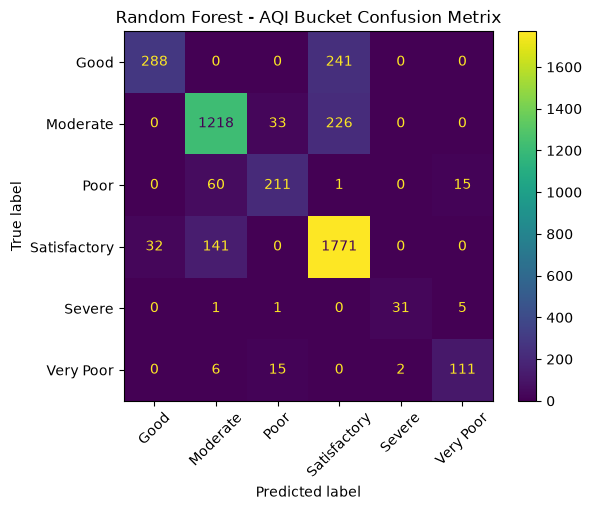

In [ ]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_clf_test_encoded , y_pred_clf) 

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm , 
    display_labels = label_encoder.classes_
)

disp.plot(xticks_rotation = 45) 
plt.title("Random Forest - AQI Bucket Confusion Metrix")
plt.show() 

The confusion matrix shows that the Random Forest classifier correctly classified most samples along the main diagonal. The largest misclassification occurred between the Good and Satisfactory categories, with 241 actual Good samples predicted as Satisfactory. This explains the relatively low recall of 0.54 for the Good class, while Satisfactory achieved a high recall of 0.91.

In [ ]:
clf_feature_importance = pd.Series(
    rf_clf.feature_importances_ , 
    index = x_train.columns
).sort_values(ascending=False)

print(clf_feature_importance.head(15))

PM2.5             0.164681
PM2.5_lag1        0.151607
PM10              0.115366
CO                0.095266
PM2.5_rolling3    0.085058
O3                0.044187
SO2               0.042350
NOx               0.041685
NO2               0.041354
NO                0.040451
Toluene           0.033053
NH3               0.029060
Benzene           0.027721
Month             0.018752
Year              0.017404
dtype: float64


Feature importance analysis showed that PM2.5 was the most influential predictor (0.1647), followed by PM2.5_lag1 (0.1516), PM10 (0.1154), CO (0.0953), and PM2.5_rolling3 (0.0851). The importance of lag and rolling-average features indicates that recent PM2.5 patterns contributed meaningfully to AQI Bucket classification.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100 ,200 ,300],
    "max_depth": [ 10,20,30,None],
    "min_samples_split": [2 ,5 ,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt", "log2"]
}

rf_classifier = RandomForestClassifier(
    random_state = 42,
    n_jobs=-1 
)

random_search = RandomizedSearchCV(
    estimator= rf_classifier,
    param_distributions=param_dist,
    n_iter = 15,
    cv=3,
    scoring="f1_weighted" ,
    n_jobs = -1,
    random_state = 42,
    verbose=1
)

random_search.fit(x_train , y_clf_train_encoded)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
0.672602452919063


In [ ]:
best_rf_clf = random_search.best_estimator_

y_pred_tuned = best_rf_clf.predict(x_test)

accuracy_tuned = accuracy_score(
    y_clf_test_encoded,
    y_pred_tuned
)

print("Tuned Accuracy:" , accuracy_tuned)

print(classification_report(
    y_clf_test_encoded,
    y_pred_tuned,
    target_names = label_encoder.classes_
))

Tuned Accuracy: 0.8271716942617373
              precision    recall  f1-score   support

        Good       0.93      0.55      0.69       529
    Moderate       0.86      0.82      0.84      1477
        Poor       0.81      0.72      0.76       287
Satisfactory       0.79      0.92      0.85      1944
      Severe       0.91      0.82      0.86        38
   Very Poor       0.84      0.84      0.84       134

    accuracy                           0.83      4409
   macro avg       0.86      0.78      0.81      4409
weighted avg       0.83      0.83      0.82      4409



Hyperparameter tuning resulted in a marginal improvement in test accuracy from 82.33% to 82.72%, while the overall weighted F1-score remained approximately 0.82.

Final Classifier: Tuned Random Forest Classifier
Accuracy: 82.72%
Weighted F1-score: ~0.82

In [ ]:
import joblib

# Save the trained regression model
joblib.dump(rf_tuned, "aqi_regression_model.pkl")

print("Regression model saved successfully!")

# Load the saved model
loaded_reg_model = joblib.load("aqi_regression_model.pkl")

# Compare prediction from original and loaded model
print(
    "Original model:",
    rf_tuned.predict(x_test.iloc[:1])
)

print(
    "Loaded model:",
    loaded_reg_model.predict(x_test.iloc[:1])
)

Regression model saved successfully!
Original model: [179.54036735]
Loaded model: [179.54036735]


I used Joblib to serialize and save the trained Random Forest model so that it could be loaded directly during deployment without retraining the model. I also verified the saved model by comparing predictions from the original and loaded models on the same test input.

In [ ]:
regression_features = x_train.columns.tolist()

print("Total regression features:" , len(regression_features))
print(regression_features)

joblib.dump(regression_features , "regression_features.pkk")
print("regression_features list save successfully!")



Total regression features: 40
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Year', 'Month', 'PM2.5_lag1', 'PM2.5_rolling3', 'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher', 'City_Thiruvananthapuram', 'City_Visakhapatnam', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter']
regression_features list save successfully!


In [ ]:
classification_features = x_train.columns.tolist()

print("Total classification features:", len(classification_features))
print(classification_features)

classification_features = x_train.columns.tolist()

joblib.dump(
    classification_features,
    "classification_features.pkl"
)

print("Classification feature list saved successfully!")

Total classification features: 40
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Year', 'Month', 'PM2.5_lag1', 'PM2.5_rolling3', 'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal', 'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai', 'City_Coimbatore', 'City_Delhi', 'City_Gurugram', 'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai', 'City_Patna', 'City_Shillong', 'City_Talcher', 'City_Thiruvananthapuram', 'City_Visakhapatnam', 'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter']
Classification feature list saved successfully!


In [ ]:
from pathlib import Path
# Create models folder

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

print("model folder ready!")

model folder ready!


In [103]:
from pathlib import Path
import shutil

# Create models folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# List of model files
model_files = [
    "aqi_regression_model.pkl",
    "aqi_classifier_model.pkl",
    "aqi_label_encoder.pkl",
    "regression_features.pkl",
    "classification_features.pkl"
]

# Move files to models folder
for file in model_files:
    source = Path(file)
    destination = models_dir / file

    if source.exists():
        shutil.move(str(source), str(destination))
        print(f"{file} moved successfully!")
    elif destination.exists():
        print(f"{file} already exists in models folder!")
    else:
        print(f"{file} not found!")

aqi_regression_model.pkl moved successfully!
aqi_classifier_model.pkl moved successfully!
aqi_label_encoder.pkl moved successfully!
regression_features.pkl not found!
classification_features.pkl moved successfully!


In [106]:
import joblib
from pathlib import Path
import shutil

# --------------------------------------------------
# 1. Create models folder
# --------------------------------------------------

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)


# --------------------------------------------------
# 2. Save regression model
# --------------------------------------------------

joblib.dump(
    rf_tuned,
    models_dir / "aqi_regression_model.pkl"
)

print("Regression model saved!")


# --------------------------------------------------
# 3. Save classifier model
# --------------------------------------------------

joblib.dump(
    rf_clf,
    models_dir / "aqi_classifier_model.pkl"
)

print("Classification model saved!")


# --------------------------------------------------
# 4. Save label encoder
# --------------------------------------------------

joblib.dump(
    label_encoder,
    models_dir / "aqi_label_encoder.pkl"
)

print("Label encoder saved!")


# --------------------------------------------------
# 5. Create and save regression feature list
# --------------------------------------------------

regression_features = x_train.columns.tolist()

joblib.dump(
    regression_features,
    models_dir / "regression_features.pkl"
)

print("Regression feature list saved!")


# --------------------------------------------------
# 6. Create classifier feature list
# --------------------------------------------------

# Your classifier was trained with X_train
classification_features = x_train.columns.tolist()

joblib.dump(
    classification_features,
    models_dir / "classification_features.pkl"
)

print("Classification feature list saved!")


# --------------------------------------------------
# 7. Verify all files
# --------------------------------------------------

print("\nFiles inside models folder:")

for file in models_dir.iterdir():
    print("-", file.name)

Regression model saved!
Classification model saved!
Label encoder saved!
Regression feature list saved!
Classification feature list saved!

Files inside models folder:
- aqi_classifier_model.pkl
- aqi_label_encoder.pkl
- aqi_regression_model.pkl
- classification_features.pkl
- regression_features.pkl


In [108]:
import streamlit as st
import joblib
import pandas as pd
from pathlib import Path


# ==================================================
# PAGE CONFIGURATION
# ==================================================

st.set_page_config(
    page_title="AQI Prediction India",
    page_icon="🌍",
    layout="wide"
)


# ==================================================
# LOAD MODELS AND ARTIFACTS
# ==================================================

MODELS_DIR = Path("models")

regression_model = joblib.load(
    MODELS_DIR / "aqi_regression_model.pkl"
)

classifier_model = joblib.load(
    MODELS_DIR / "aqi_classifier_model.pkl"
)

label_encoder = joblib.load(
    MODELS_DIR / "aqi_label_encoder.pkl"
)

regression_features = joblib.load(
    MODELS_DIR / "regression_features.pkl"
)

classification_features = joblib.load(
    MODELS_DIR / "classification_features.pkl"
)


# ==================================================
# TITLE
# ==================================================

st.title("🌍 India AQI Prediction System")

st.write(
    "Predict Air Quality Index (AQI) and AQI Category "
    "using Machine Learning."
)

st.divider()


# ==================================================
# USER INPUT SECTION
# ==================================================

st.subheader("Enter Air Pollutant Values")

col1, col2, col3 = st.columns(3)


with col1:
    pm25 = st.number_input(
        "PM2.5",
        min_value=0.0,
        value=50.0
    )

    pm10 = st.number_input(
        "PM10",
        min_value=0.0,
        value=80.0
    )

    no = st.number_input(
        "NO",
        min_value=0.0,
        value=10.0
    )

    no2 = st.number_input(
        "NO2",
        min_value=0.0,
        value=20.0
    )

    nox = st.number_input(
        "NOx",
        min_value=0.0,
        value=30.0
    )


with col2:
    nh3 = st.number_input(
        "NH3",
        min_value=0.0,
        value=10.0
    )

    co = st.number_input(
        "CO",
        min_value=0.0,
        value=1.0
    )

    so2 = st.number_input(
        "SO2",
        min_value=0.0,
        value=10.0
    )

    o3 = st.number_input(
        "O3",
        min_value=0.0,
        value=30.0
    )

    benzene = st.number_input(
        "Benzene",
        min_value=0.0,
        value=1.0
    )


with col3:
    toluene = st.number_input(
        "Toluene",
        min_value=0.0,
        value=1.0
    )

    year = st.number_input(
        "Year",
        min_value=2015,
        value=2026
    )

    month = st.selectbox(
        "Month",
        list(range(1, 13))
    )


# ==================================================
# CITY AND SEASON
# ==================================================

st.subheader("Location and Time Information")

col1, col2 = st.columns(2)


cities = [
    "Ahmedabad",
    "Amaravati",
    "Amritsar",
    "Bengaluru",
    "Bhopal",
    "Brajrajnagar",
    "Chandigarh",
    "Chennai",
    "Coimbatore",
    "Delhi",
    "Gurugram",
    "Guwahati",
    "Hyderabad",
    "Jaipur",
    "Jorapokhar",
    "Kolkata",
    "Lucknow",
    "Mumbai",
    "Patna",
    "Shillong",
    "Talcher",
    "Thiruvananthapuram",
    "Visakhapatnam"
]


with col1:
    city = st.selectbox(
        "Select City",
        cities
    )


with col2:
    season = st.selectbox(
        "Select Season",
        [
            "Winter",
            "Summer",
            "Monsoon",
            "Post-Monsoon"
        ]
    )


# ==================================================
# PM2.5 HISTORICAL FEATURES
# ==================================================

st.subheader("PM2.5 Historical Information")

col1, col2 = st.columns(2)


with col1:
    pm25_lag1 = st.number_input(
        "Previous PM2.5 Value",
        min_value=0.0,
        value=pm25
    )


with col2:
    pm25_rolling3 = st.number_input(
        "3-Day Average PM2.5",
        min_value=0.0,
        value=pm25
    )


# ==================================================
# PREDICTION BUTTON
# ==================================================

if st.button(
    "Predict AQI",
    use_container_width=True
):

    # ==============================================
    # CREATE RAW INPUT
    # ==============================================

    input_data = {
        "PM2.5": pm25,
        "PM10": pm10,
        "NO": no,
        "NO2": no2,
        "NOx": nox,
        "NH3": nh3,
        "CO": co,
        "SO2": so2,
        "O3": o3,
        "Benzene": benzene,
        "Toluene": toluene,
        "Year": year,
        "Month": month,
        "PM2.5_lag1": pm25_lag1,
        "PM2.5_rolling3": pm25_rolling3
    }


    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([input_data])


    # ==============================================
    # ADD MISSING REGRESSION FEATURES
    # ==============================================

    for feature in regression_features:

        if feature not in input_df.columns:
            input_df[feature] = 0


    # ==============================================
    # ENCODE CITY
    # ==============================================

    city_column = f"City_{city}"

    if city_column in regression_features:
        input_df[city_column] = 1


    # ==============================================
    # ENCODE SEASON
    # ==============================================

    season_column = f"Season_{season}"

    if season_column in regression_features:
        input_df[season_column] = 1


    # ==============================================
    # REGRESSION INPUT
    # EXACT SAME FEATURE ORDER AS TRAINING
    # ==============================================

    regression_input = input_df.reindex(
        columns=regression_features,
        fill_value=0
    )


    # ==============================================
    # AQI REGRESSION PREDICTION
    # ==============================================

    predicted_aqi = regression_model.predict(
        regression_input
    )[0]


    # ==============================================
    # CLASSIFICATION INPUT
    # EXACT SAME FEATURE ORDER AS TRAINING
    # ==============================================

    classification_input = input_df.reindex(
        columns=classification_features,
        fill_value=0
    )


    # ==============================================
    # AQI BUCKET CLASSIFICATION
    # ==============================================

    predicted_class = classifier_model.predict(
        classification_input
    )

    predicted_bucket = label_encoder.inverse_transform(
        predicted_class
    )[0]


    # ==============================================
    # DISPLAY RESULTS
    # ==============================================

    st.divider()

    st.subheader("Prediction Results")

    result_col1, result_col2 = st.columns(2)


    with result_col1:

        st.metric(
            "Predicted AQI",
            f"{predicted_aqi:.2f}"
        )


    with result_col2:

        st.metric(
            "Predicted AQI Category",
            predicted_bucket
        )


    st.success(
        "Prediction completed successfully!"
    )

2026-08-29 10:17:06.296 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-08-29 10:17:07.034 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.872 
  command:

    streamlit run c:\Users\yash1\Desktop\AQI-Prediction-India\venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-29 10:17:07.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.883 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-29 10:17:07.888